In [1]:
import cv2
import os
import matplotlib.pyplot as plt

In [2]:
image_path = 'Sukuna.jpg'
if not os.path.exists(image_path):
    raise FileNotFoundError(f"{image_path} does not exist")
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
img.shape

(194, 259)

In [3]:
_, global_thresh = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
adaptive_thresh = cv2.adaptiveThreshold(
    img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2
)

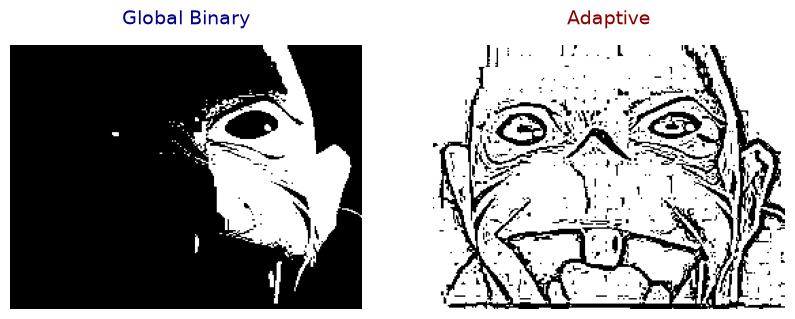

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(global_thresh, cmap='gray')
axes[0].axis('off')
axes[0].set_title("Global Binary", fontsize=14, color='darkblue', pad=15)

axes[1].imshow(adaptive_thresh, cmap='gray')
axes[1].axis('off')
axes[1].set_title("Adaptive", fontsize=14, color='darkred', pad=15)

plt.show()

In [5]:
N, M = adaptive_thresh.shape
center = (M // 2, N // 2)

rot_mat = cv2.getRotationMatrix2D(center, 45, 0.8)
rotated = cv2.warpAffine(adaptive_thresh, rot_mat, (M, N))

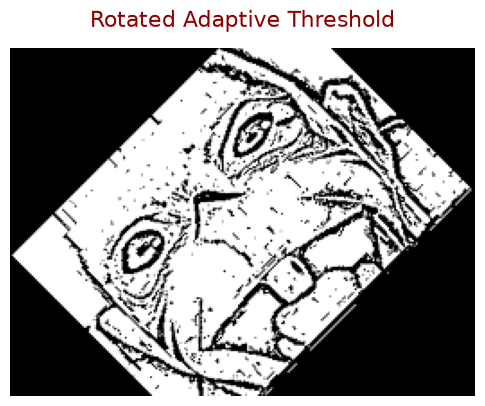

In [6]:
plt.figure(figsize=(6, 6))
plt.axis('off')

plt.imshow(rotated, cmap='gray')
plt.title("Rotated Adaptive Threshold", fontsize=16, color='darkred', pad=15)
plt.show()